Computer Vision Assignment : MNIST Dataset - Classifying Handwritten Digits

MNIST Dataset :
The MNIST dataset consists of 70,000(train -60k,test-10k) images of handwritten digits from 0-9. The images if of 28x28 pixel and we have roughly equal distribution across all the classes.
The goal of this project is to be able to correctly classify the handwritten digits from 0-9.



In [ ]:
#Importing required libraries and tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,

)


# --- Reproducibility ---
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed(SEED)
  torch.cuda.manual_seed_all(SEED)




In [ ]:
train_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081))  #MNIST Mean and STD
])

test_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081))  #MNIST Mean and STD
])

train_dataset = datasets.MNIST(root='./data', train=True,
                                download=True, transform=train_transform)
test_dataset  = datasets.MNIST(root='./data', train=False,
                                download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

Training sample:60000
Testing sample:10000
Image shape: torch.Size([1, 28, 28])
Label: 5
Class:0, Count:5923
Class:1, Count:6742
Class:2, Count:5958
Class:3, Count:6131
Class:4, Count:5842
Class:5, Count:5421
Class:6, Count:5918
Class:7, Count:6265
Class:8, Count:5851
Class:9, Count:5949


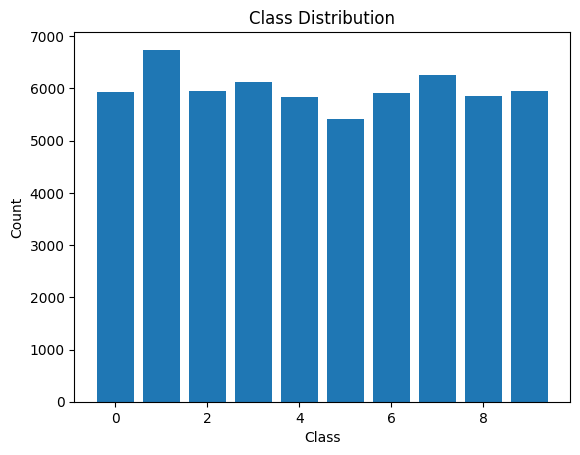

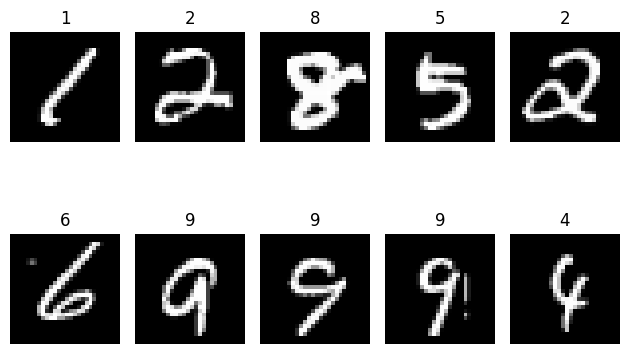

In [ ]:
# Lets explore out test and train datasets
print(f'Training sample:{len(train_dataset)}')
print(f'Testing sample:{len(test_dataset)}')
# One sample of Dataset
image,label=train_dataset[0]
print("Image shape:", image.shape)  #[1,28,28] ,1->greyscale and 28x28 pixel
print("Label:", label)
# Now check for class distribution . Need to see if we have any class imbalance
from collections import Counter
label_lists=[labels for _,labels in train_dataset]
count=Counter(label_lists)    # here in label_list we make a list of all class 0-9 and storing the count of each class for instance -> {1:20,2:40,3:60 }

for digit in sorted(count):
  print(f'Class:{digit}, Count:{count[digit]}')

plt.bar(count.keys(),count.values())
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

# Lets Visualize few image from our train set
# Our images are normalized so we need to un-normalize first
images,labels=next(iter(train_loader))
fig,axes=plt.subplots(2,5)

for i in range(10):
  img=images[i]* 0.3081 + 0.1307  # unnormalize
  ax=axes[i//5,i%5]                     # creating axes position axes[0,0],axes[0,1],axes[0,2],........ image position axes[r,c]
  ax.imshow(img.squeeze(), cmap='gray')   #img.squeeze-> removes extra dimension from 1,28,28 -> 28,28
  ax.set_title(labels[i].item())
  ax.axis('off')

plt.tight_layout()
plt.show()



In [ ]:
from torch.nn.modules.activation import ReLU
# Model set up
class CNN(nn.Module):           #nn.Module-> base class for all Pytorch modules
  def __init__(self):
    super(CNN,self).__init__()    #Calls the constructor of nn.Module

#feature Extractor
    self.features=nn.Sequential(
     nn.Conv2d(1,32,kernel_size=3,padding=1),   #(32,28,28)
     nn.ReLU(),
     nn.MaxPool2d(2,2),                         #(32,14,14)

     nn.Conv2d(32,64,kernel_size=3,padding=1),   #(64,14,14)
     nn.ReLU(),
     nn.MaxPool2d(2,2),                          #(64,7,7)
)
#classifier Head
    self.classifier=nn.Sequential(
     nn.Flatten(),
     nn.Linear(64*7*7,128),     #3136->128
     nn.ReLU(),
     nn.Dropout(0.5),
     nn.Linear(128,10),
)

  def forward(self,x):
    x=self.features(x)
    x=self.classifier(x)
    return x






In [ ]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
#Train the Model
def train(model,loader,criterion,optimizer,device):
  model.train()
  total_loss,correct=0,0

  for images,labels in loader:
    images,labels=images.to(device),labels.to(device)

    optimizer.zero_grad()   # very impt step -> clears old gradients
    output=model(images)    # forward pass
    loss=criterion(output,labels)
    loss.backward()             # backward propagation
    optimizer.step()           #updates the weights

    total_loss +=loss.item()      # tracking sum of losses over batches, .item()  -> converts tensor to python number
    correct += (output.argmax(1)==labels).sum().item()    # outputs.argmax(1) picks the predicted class index for each sample.

  avg_loss=total_loss/len(loader)
  accuracy=100* correct/len(loader.dataset)
  return avg_loss, accuracy



In [ ]:
#Evaluate the model
def evaluate(model,loader,criterion,device):
  model.eval()
  total_loss,correct=0,0
  all_labels=[]
  all_preds=[]

  with torch.no_grad():
    for images,labels in loader:
      images,labels=images.to(device),labels.to(device)

      output=model(images)
      loss=criterion(output,labels)
      total_loss +=loss.item()
      correct +=(output.argmax(1)==labels).sum().item()
      #store labels and predictions
      preds=output.argmax(1)
      all_labels.extend(labels.cpu().numpy())
      all_preds.extend(preds.cpu().numpy())

    avg_loss=total_loss/len(loader)
    accuracy=100*correct/len(loader.dataset)
    return avg_loss, accuracy,all_labels,all_preds

In [ ]:
#Run your model
for epoch in range(1,6):
  train_loss,train_acc=train(model,train_loader,criterion,optimizer,device)
  test_loss,test_acc,all_labels,all_preds=evaluate(model,test_loader,criterion,device)
  print(f'Epoch {epoch} | Train {train_acc:.1f}%| Test {test_acc:.1f}%')


Epoch 1 | Train 93.4%| Test 98.4%
Epoch 2 | Train 97.6%| Test 99.0%
Epoch 3 | Train 98.3%| Test 99.1%
Epoch 4 | Train 98.6%| Test 99.1%
Epoch 5 | Train 98.8%| Test 99.1%


Final Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Confusion Matrix:


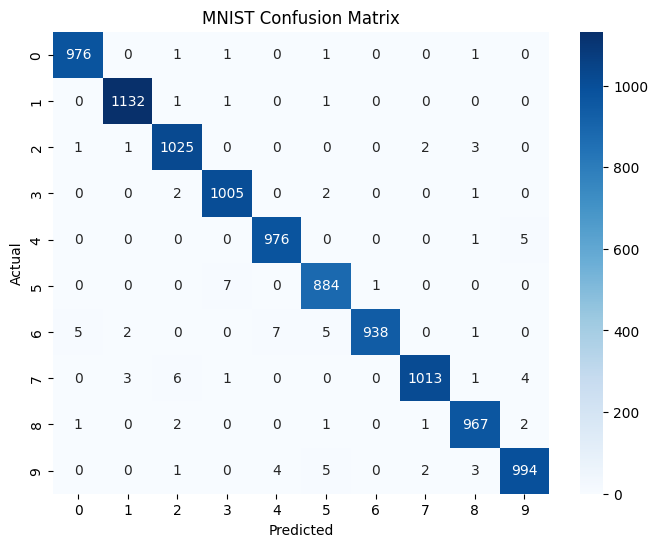

In [ ]:
print('Final Classification Report:')
print(classification_report(all_labels, all_preds))

print('Confusion Matrix:')
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix")
plt.show()

In [ ]:
# Verify with code:
total = sum(p.numel() for p in model.parameters())    #model.parameters() → gives all parameters (weights + biases) in the model
#p.numel() → returns the number of elements in that tensor.
#Example: a weight matrix of shape [10, 5] has 10 × 5 = 50 elements.
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total:     {total:,}")
print(f"Trainable: {trainable:,}")

Total:     421,642
Trainable: 421,642
